# 06 — village gap (the answer table)

**What this notebook does.** One row per BushTel village (792), with every infrastructure
fact *measured from that village*: how far to the nearest carrier tower, how many towers /
carriers / networks within 10 km, whether it sits inside an NBN fixed footprint, how far to
the nearest built and nearest funded-but-unbuilt Mobile Black Spot site, what the coverage
guide claims for it, and whether it has a RICT public-access point nearby. It ends with a
single triage flag, `distance_gap_candidate`, and an empty `tier` column for you to define.

**Every distance in this notebook is straight-line, in EPSG:3577 (metres).** It is triage —
"is a service plausibly in reach" — **not** a coverage claim, a drive time, or a signal
prediction. The markdown above each distance step repeats this.

**What it reads** — outputs of 01 / 03 / 04 / 05 only (the 06–07 rule):

| dataframe | file | from |
|---|---|---|
| `villages_gdf` | `data/processed/villages.geojson` | nb 01 — the spine (792 rows) |
| `towers_df` | `data/processed/towers.csv` | nb 03 — carrier handset-band towers (431) |
| `nbn_footprint_gdf` | `data/processed/nbn_footprint.geojson` | nb 04 — 2 dissolved polygons |
| `program_sites_df` | `data/processed/program_sites.csv` | nb 05 — mbsp / guide / rict (533) |

**What it writes** (`data/processed/`):

| file | one row is | key | rows |
|---|---|---|---|
| `village_gap.csv` | one village + its gap measures | `community_id` | 792 |
| `village_gap.geojson` | same, as points (EPSG:4326) | `community_id` | 792 |

**No population column here** — population is an SA1 fact (nb 02) and is deliberately not joined onto
villages: one SA1 can hold many villages and its census count can't be split between them.

**Decisions applied** (`PROJECT_CONTEXT.md` §11):
- The 1 `is_planning_site` tower (Darwin placeholder) is **excluded** from tower-distance work.
- `n_carriers_10km` **and** `n_networks_10km` both carried (networks = redundancy).
- Guide name match is against the **nearest** guide place only; `guide_matched_by` ∈
  {distance, name, both, neither}; the "No aliases recorded" sentinel is treated as empty.
- RICT: all 4 `site_type` codes count; `has_rict_public_access` = any RICT site within
  `RICT_MATCH_KM`; also `n_rict_sites`, `rict_site_type` (`;`-joined codes).
- `distance_gap_candidate` = guide does **not** claim macro/small **and** `km_nearest_tower`
  > `GAP_KM`. Unmatched-by-guide counts as "no claim". It is **not** `likely_gap`.
- `tier` is a stub (`<NA>`) with a TODO — T1–T5 to be defined after this table is reviewed.

In [1]:
# Every import for the whole notebook lives in this cell.
%matplotlib inline
import os
import re
from pathlib import Path

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from shapely.geometry import LineString

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 220)

In [2]:
# --- constants used across the notebook ---
DIST_CRS       = "EPSG:3577"   # Australian Albers, metres — every distance is computed in this CRS
BUFFER_KM      = 10            # radius for the n_*_10km neighbourhood counts
GAP_KM         = 15            # distance_gap_candidate cutoff; triage only, NOT a validated coverage radius
GUIDE_MATCH_KM = 2             # a guide place this close is treated as "this village"
RICT_MATCH_KM  = 2            # a RICT site this close is treated as serving the village

VILLAGES_GEOJSON   = "data/processed/villages.geojson"
TOWERS_CSV         = "data/processed/towers.csv"
NBN_FOOTPRINT_GEOJSON = "data/processed/nbn_footprint.geojson"
PROGRAM_SITES_CSV  = "data/processed/program_sites.csv"

villages_gdf      = gpd.read_file(VILLAGES_GEOJSON)                       # 792 points, EPSG:4326
towers_df         = pd.read_csv(TOWERS_CSV)
nbn_footprint_gdf = gpd.read_file(NBN_FOOTPRINT_GEOJSON)                  # 2 polygons, EPSG:4326
program_sites_df  = pd.read_csv(PROGRAM_SITES_CSV)

OUT_DIR = Path("data/processed"); OUT_DIR.mkdir(parents=True, exist_ok=True)
EDA_PLOT_DIR = Path("docs/eda"); EDA_PLOT_DIR.mkdir(parents=True, exist_ok=True)
eda_figures = {}

def to_bool(series):
    # program_sites.csv bool columns come back as object (True/False/NaN) — normalise
    return series.astype(str).str.strip().str.lower().isin(["true", "1"])

def points_3577(df, lon="longitude", lat="latitude"):
    return gpd.GeoDataFrame(df.copy(), geometry=gpd.points_from_xy(df[lon], df[lat]),
                            crs="EPSG:4326").to_crs(DIST_CRS)

def nearest(left_pts_3577, right_gdf_3577, keep_cols, prefix):
    j = gpd.sjoin_nearest(left_pts_3577[["community_id", "geometry"]],
                          right_gdf_3577[keep_cols + ["geometry"]], how="left", distance_col="_m")
    j = j.sort_values("_m").drop_duplicates("community_id")              # ties -> keep the first
    out = j[["community_id", "_m"] + keep_cols].rename(
        columns={"_m": f"km_{prefix}", **{c: f"{prefix}_{c}" for c in keep_cols}})
    out[f"km_{prefix}"] = (out[f"km_{prefix}"] / 1000).round(3)
    return out

print(f"villages_gdf      : {len(villages_gdf)} rows, CRS {villages_gdf.crs}")
print(f"towers_df         : {len(towers_df)} rows ({int(towers_df['is_planning_site'].astype(bool).sum())} is_planning_site)")
print(f"nbn_footprint_gdf : {len(nbn_footprint_gdf)} rows -> {list(nbn_footprint_gdf['technology'])}")
print(f"program_sites_df  : {len(program_sites_df)} rows -> {program_sites_df['source'].value_counts().to_dict()}")

villages_gdf      : 792 rows, CRS EPSG:4326
towers_df         : 431 rows (1 is_planning_site)
nbn_footprint_gdf : 2 rows -> ['fixed_line', 'fixed_wireless']
program_sites_df  : 533 rows -> {'rict': 296, 'guide': 188, 'mbsp': 49}


## 1. Start from the villages (nb 01 pass-through)

`community_aliases` is carried because step 6 needs it for the guide name match.

In [3]:
PASSTHROUGH = ["community_id", "community_name", "community_aliases", "community_type",
               "latitude", "longitude", "sa1_code", "remoteness_name", "is_remote"]
village_gap_df = villages_gdf[PASSTHROUGH].copy()
village_gap_df["sa1_code"] = village_gap_df["sa1_code"].astype(str)
assert village_gap_df["community_id"].is_unique and len(village_gap_df) == 792

village_pts_3577 = villages_gdf[["community_id"]].copy()
village_pts_3577 = gpd.GeoDataFrame(village_pts_3577, geometry=villages_gdf.geometry, crs="EPSG:4326").to_crs(DIST_CRS)
print(village_gap_df.shape)
village_gap_df.head()

(792, 9)


,community_id,community_name,community_aliases,community_type,latitude,longitude,sa1_code,remoteness_name,is_remote
0,1,ADELAIDE BORE,"WOOLA,WOOLLA",Family Outstation,-22.21485,133.93607,70201105410,Very Remote Australia,True
1,2,ALYUEN,"AILERON,ALUM,ALUM CAMP",Family Outstation,-22.66949,133.35147,70201105410,Very Remote Australia,True
2,3,AKNGWERTNARRE,MORRIS SOAK,Town Camp,-23.69280,133.86120,70201104513,Remote Australia,True
3,4,ALKIPI,"ALKIPIE,ALKPIE,MOUNT LARRY,YALKIPI",Family Outstation,-23.27356,131.82924,70201105310,Very Remote Australia,True
4,5,RED SANDHILL,INTJIRRANGA,Family Outstation,-24.00974,132.85279,70201105312,Very Remote Australia,True


## 2. Nearest carrier tower (from nb 03) — *straight-line triage, not coverage*

Nearest of the 431 handset-band tower sites (minus the 1 planning placeholder). A tower this
close does not mean the village has a signal — terrain, power, and whether the site is on air
are all unknown here.

In [4]:
towers_3577 = points_3577(towers_df)
towers_for_distance_3577 = towers_3577[~towers_3577["is_planning_site"].astype(bool)].copy()
print(f"towers used for distance: {len(towers_for_distance_3577)} "
      f"(excluded {len(towers_3577) - len(towers_for_distance_3577)} is_planning_site)")

nt = nearest(village_pts_3577, towers_for_distance_3577,
             ["carriers", "networks", "spectrum_depth_khz"], "nearest_tower")
# -> columns: community_id, km_nearest_tower, nearest_tower_carriers, nearest_tower_networks,
#             nearest_tower_spectrum_depth_khz
village_gap_df = village_gap_df.merge(nt, on="community_id", how="left")
village_gap_df["km_nearest_tower"] = village_gap_df["km_nearest_tower"].round(2)

towers used for distance: 430 (excluded 1 is_planning_site)


### Validate: `km_nearest_tower` distribution, and 20 sample village → tower lines

count    792.00
mean      21.97
std       24.57
min        0.01
25%        3.50
50%       14.09
75%       31.27
max      149.56
Name: km_nearest_tower, dtype: float64
  villages >  2 km from a tower: 626
  villages >  5 km from a tower: 560
  villages > 10 km from a tower: 470
  villages > 15 km from a tower: 384
  villages > 30 km from a tower: 212
  villages > 50 km from a tower: 94


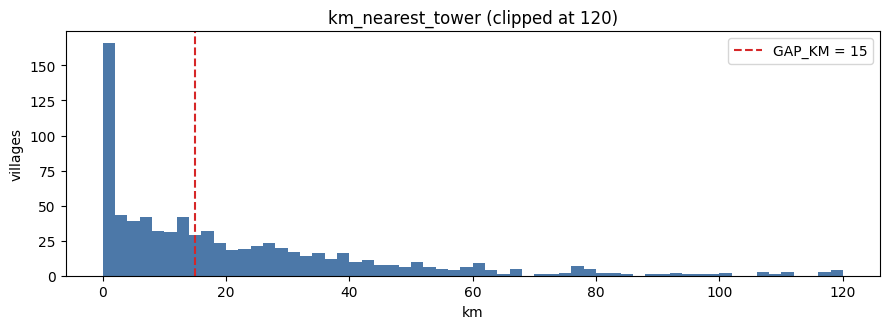

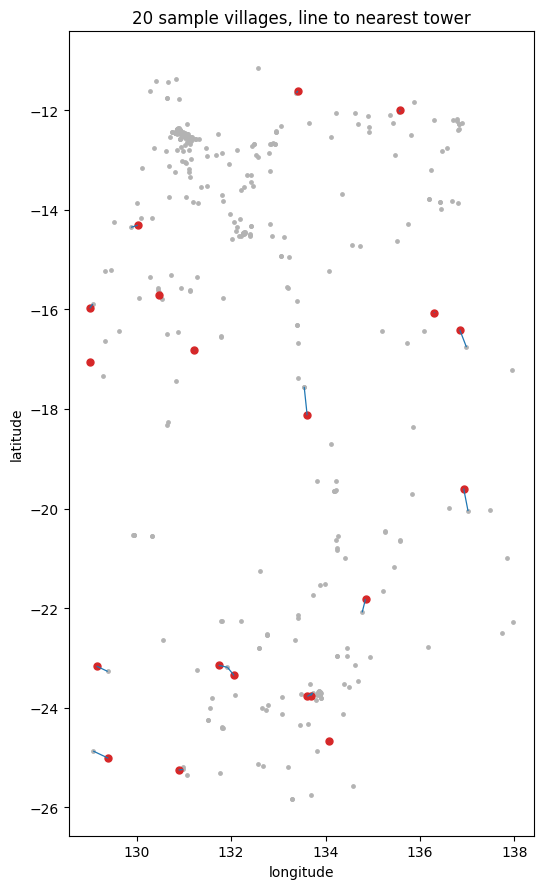

In [5]:
k = village_gap_df["km_nearest_tower"]
assert k.notna().all(), "a village has no nearest tower"
print(k.describe().round(2))
for thr in (2, 5, 10, 15, 30, 50):
    print(f"  villages > {thr:>2} km from a tower: {int((k > thr).sum())}")

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.hist(k.clip(upper=120), bins=60, color="#4c78a8")
ax.axvline(GAP_KM, color="#d62728", linestyle="--", label=f"GAP_KM = {GAP_KM}")
ax.set_title("km_nearest_tower (clipped at 120)"); ax.set_xlabel("km"); ax.set_ylabel("villages"); ax.legend()
fig.tight_layout()
eda_figures["06_km_nearest_tower_hist"] = fig

# lines for ~20 villages spread across the distance range
sample = village_gap_df.sort_values("km_nearest_tower").iloc[::len(village_gap_df) // 20][:20]
tjoin = gpd.sjoin_nearest(village_pts_3577, towers_for_distance_3577[["site_id", "geometry"]],
                          how="left", distance_col="_m").sort_values("_m").drop_duplicates("community_id")
tjoin = tjoin.merge(towers_for_distance_3577[["site_id", "geometry"]].rename(columns={"geometry": "tower_geom"}),
                    on="site_id", how="left").set_index("community_id")
lines = gpd.GeoDataFrame(
    geometry=[LineString([village_pts_3577.set_index("community_id").loc[cid, "geometry"],
                          tjoin.loc[cid, "tower_geom"]]) for cid in sample["community_id"]],
    crs=DIST_CRS).to_crs("EPSG:4326")

fig, ax = plt.subplots(figsize=(7.5, 9))
towers_for_distance_3577.to_crs("EPSG:4326").plot(ax=ax, color="0.7", markersize=6)
lines.plot(ax=ax, color="#1f77b4", linewidth=0.9)
villages_gdf[villages_gdf["community_id"].isin(sample["community_id"])].plot(ax=ax, color="#d62728", markersize=25)
ax.set_title("20 sample villages, line to nearest tower")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
fig.tight_layout()
eda_figures["06_sample_village_tower_lines"] = fig

## 3. Towers / carriers / networks within 10 km (from nb 03) — *straight-line*

A 10 km disc around each village. `n_networks_10km` is the redundancy number: two brands of
one physical network (Vodafone + TPG) count once.

In [6]:
village_buffers_3577 = village_pts_3577.copy()
village_buffers_3577["geometry"] = village_buffers_3577.buffer(BUFFER_KM * 1000)

hits = gpd.sjoin(village_buffers_3577, towers_for_distance_3577[["site_id", "carriers", "networks", "geometry"]],
                 how="left", predicate="intersects")

def count_tokens(series):
    return len({t for v in series.dropna() for t in str(v).split(";") if t})

grp = hits.groupby("community_id")
counts_10km = pd.DataFrame({
    "n_towers_10km":   grp["site_id"].nunique(),
    "n_carriers_10km": grp["carriers"].apply(count_tokens),
    "n_networks_10km": grp["networks"].apply(count_tokens),
}).reset_index()
village_gap_df = village_gap_df.merge(counts_10km, on="community_id", how="left")
for c in ("n_towers_10km", "n_carriers_10km", "n_networks_10km"):
    village_gap_df[c] = village_gap_df[c].fillna(0).astype(int)

### Validate: the 10 km counts

In [7]:
print(village_gap_df[["n_towers_10km", "n_carriers_10km", "n_networks_10km"]].describe().round(2))
print("\nn_towers_10km value counts (0 = no tower within 10 km):")
print(village_gap_df["n_towers_10km"].value_counts().sort_index())
print(f"\nvillages with 0 towers within 10 km : {int((village_gap_df['n_towers_10km'] == 0).sum())}")
# sanity: every village with n_towers_10km > 0 must have km_nearest_tower <= 10
bad = village_gap_df[(village_gap_df["n_towers_10km"] > 0) & (village_gap_df["km_nearest_tower"] > 10)]
print(f"inconsistent rows (count>0 but nearest>10 km): {len(bad)}  (should be 0)")
assert len(bad) == 0

       n_towers_10km  n_carriers_10km  n_networks_10km
count         792.00           792.00           792.00
mean            1.74             0.65             0.61
std             7.28             1.02             0.90
min             0.00             0.00             0.00
25%             0.00             0.00             0.00
50%             0.00             0.00             0.00
75%             1.00             1.00             1.00
max            80.00             4.00             3.00

n_towers_10km value counts (0 = no tower within 10 km):
n_towers_10km
0     470
1     215
2      44
3      18
4      11
5       1
10      3
13      1
17      1
18      1
19      4
20     10
21      1
22      4
35      1
40      1
60      1
68      1
72      1
77      1
78      1
80      1
Name: count, dtype: int64

villages with 0 towers within 10 km : 470
inconsistent rows (count>0 but nearest>10 km): 0  (should be 0)


## 4. Inside an NBN fixed footprint? (from nb 04)

Point-in-polygon, not a distance. From nb 04 we expect ~30 villages inside fixed-line and 1
inside fixed-wireless — almost every remote village is outside both (Sky Muster country).

In [8]:
fl_poly = nbn_footprint_gdf.loc[nbn_footprint_gdf["technology"] == "fixed_line", "geometry"].iloc[0]
fw_poly = nbn_footprint_gdf.loc[nbn_footprint_gdf["technology"] == "fixed_wireless", "geometry"].iloc[0]

nbn_flags = pd.DataFrame({
    "community_id": villages_gdf["community_id"].values,
    "in_nbn_fixed_line":     villages_gdf.within(fl_poly).values,
    "in_nbn_fixed_wireless": villages_gdf.within(fw_poly).values,
})
village_gap_df = village_gap_df.merge(nbn_flags, on="community_id", how="left")
print(f"in_nbn_fixed_line     : {int(village_gap_df['in_nbn_fixed_line'].sum())}")
print(f"in_nbn_fixed_wireless : {int(village_gap_df['in_nbn_fixed_wireless'].sum())}")
print(f"inside either         : {int((village_gap_df['in_nbn_fixed_line'] | village_gap_df['in_nbn_fixed_wireless']).sum())}")

in_nbn_fixed_line     : 30
in_nbn_fixed_wireless : 1
inside either         : 31


### Validate: map of villages inside vs outside a footprint

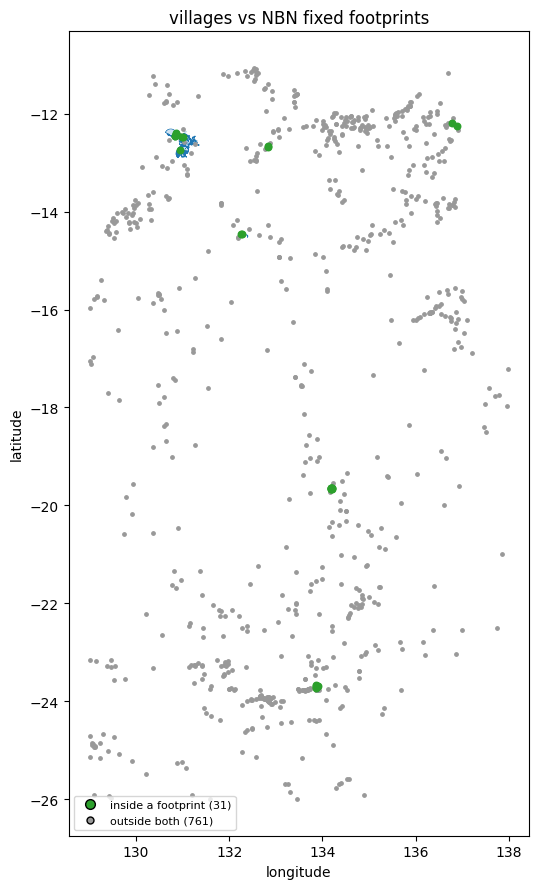

In [9]:
inside_any = village_gap_df["in_nbn_fixed_line"] | village_gap_df["in_nbn_fixed_wireless"]
fig, ax = plt.subplots(figsize=(7.5, 9))
nbn_footprint_gdf.plot(ax=ax, color="#cfe3f3", edgecolor="#1f77b4", linewidth=0.4)
villages_gdf[~inside_any.values].plot(ax=ax, color="0.6", markersize=6)
villages_gdf[inside_any.values].plot(ax=ax, color="#2ca02c", markersize=22)
ax.legend(handles=[Line2D([], [], marker="o", color="none", markerfacecolor="#2ca02c", markersize=7,
                          label=f"inside a footprint ({int(inside_any.sum())})"),
                   Line2D([], [], marker="o", color="none", markerfacecolor="0.6", markersize=5,
                          label=f"outside both ({int((~inside_any).sum())})")],
          fontsize=8, loc="lower left")
ax.set_title("villages vs NBN fixed footprints")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
fig.tight_layout()
eda_figures["06_villages_vs_nbn"] = fig

## 5. Nearest MBSP funded site — built and unbuilt (from nb 05) — *straight-line*

Split the 49 MBSP sites into **built** (41) and **funded but not built** (8). Straight-line
distance to the nearest of each; the unbuilt distance says "how close is committed funding
that hasn't landed yet". With only 8 unbuilt sites the number can be large — the km value is
the qualifier, there is no cutoff.

In [10]:
mbsp_df = program_sites_df[program_sites_df["source"] == "mbsp"].copy()
mbsp_df["mbsp_built"] = to_bool(mbsp_df["mbsp_built"])
mbsp_3577 = points_3577(mbsp_df)
built_3577   = mbsp_3577[mbsp_3577["mbsp_built"]]
unbuilt_3577 = mbsp_3577[~mbsp_3577["mbsp_built"]]
print(f"MBSP built {len(built_3577)} / unbuilt {len(unbuilt_3577)}")

nb_built = nearest(village_pts_3577, built_3577, ["program_site_id"], "nearest_built_mbsp")
nb_unbuilt = nearest(village_pts_3577, unbuilt_3577, ["program_site_id", "mbsp_round"], "nearest_unbuilt_mbsp")

village_gap_df = village_gap_df.merge(
    nb_built[["community_id", "km_nearest_built_mbsp"]], on="community_id", how="left")
village_gap_df = village_gap_df.merge(
    nb_unbuilt[["community_id", "km_nearest_unbuilt_mbsp", "nearest_unbuilt_mbsp_mbsp_round"]]
        .rename(columns={"nearest_unbuilt_mbsp_mbsp_round": "nearest_unbuilt_mbsp_round"}),
    on="community_id", how="left")
village_gap_df["km_nearest_built_mbsp"] = village_gap_df["km_nearest_built_mbsp"].round(2)
village_gap_df["km_nearest_unbuilt_mbsp"] = village_gap_df["km_nearest_unbuilt_mbsp"].round(2)

MBSP built 41 / unbuilt 8


### Validate: MBSP distance distributions

       km_nearest_built_mbsp  km_nearest_unbuilt_mbsp
count                  792.0                    792.0
mean                   131.5                    234.4
std                    106.3                    147.0
min                      0.0                      0.1
25%                     53.2                    111.7
50%                    101.8                    219.2
75%                    185.7                    334.2
max                    438.6                    748.6

nearest_unbuilt_mbsp_round mix:
nearest_unbuilt_mbsp_round
Round 7    778
Round 5     14
Name: count, dtype: int64


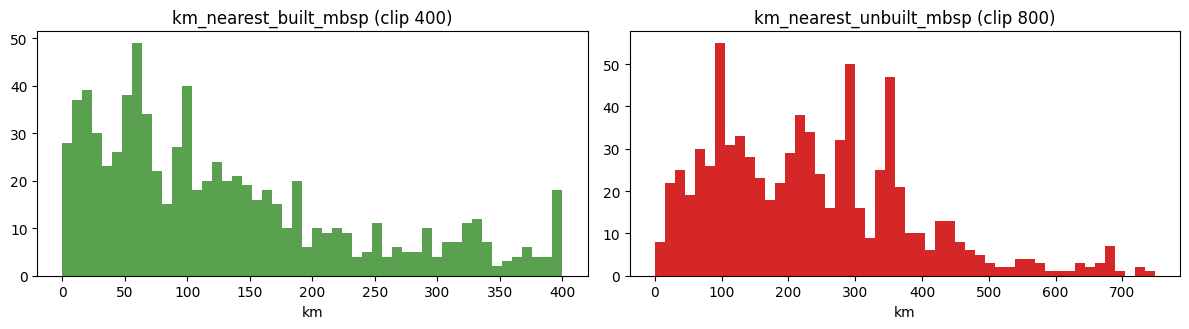

In [11]:
print(village_gap_df[["km_nearest_built_mbsp", "km_nearest_unbuilt_mbsp"]].describe().round(1))
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
axes[0].hist(village_gap_df["km_nearest_built_mbsp"].clip(upper=400), bins=50, color="#59a14f")
axes[0].set_title("km_nearest_built_mbsp (clip 400)"); axes[0].set_xlabel("km")
axes[1].hist(village_gap_df["km_nearest_unbuilt_mbsp"].clip(upper=800), bins=50, color="#d62728")
axes[1].set_title("km_nearest_unbuilt_mbsp (clip 800)"); axes[1].set_xlabel("km")
fig.tight_layout()
eda_figures["06_mbsp_distance_hist"] = fig
print("\nnearest_unbuilt_mbsp_round mix:")
print(village_gap_df["nearest_unbuilt_mbsp_round"].value_counts())

## 6. Coverage-guide read (from nb 05) — *straight-line + name match*

Take the **nearest** guide place to each village. It is a match if it is within
`GUIDE_MATCH_KM` (`guide_matched_by = distance`) **or** its `SITE NAME` equals the village's
`community_name` or one of its `community_aliases` (`= name`); both → `both`; neither →
`neither` and every `guide_*` field is NaN.

`guide_says_covered` = the matched place has macro **or** small.
`guide_proximity_only` = it has proximity **and not** macro/small — the guide claims coverage
"from a cell elsewhere". 00b showed 10 of those are >15 km from any real tower, so this stays
a *separate* column from the measured distance.

In [12]:
guide_df = program_sites_df[program_sites_df["source"] == "guide"].copy()
for c in ("guide_macro", "guide_small", "guide_proximity"):
    guide_df[c] = to_bool(guide_df[c])
guide_3577 = points_3577(guide_df)

ng = gpd.sjoin_nearest(
    village_pts_3577[["community_id", "geometry"]],
    guide_3577[["name", "guide_macro", "guide_small", "guide_proximity", "geometry"]],
    how="left", distance_col="_m").sort_values("_m").drop_duplicates("community_id")
ng["_guide_km"] = (ng["_m"] / 1000).round(3)
village_gap_df = village_gap_df.merge(
    ng[["community_id", "name", "_guide_km", "guide_macro", "guide_small", "guide_proximity"]]
        .rename(columns={"name": "_guide_name"}),
    on="community_id", how="left")

def norm(s):
    return re.sub(r"[^a-z0-9]+", " ", str(s).lower()).strip()

ALIAS_SENTINEL = "no aliases recorded"
def alias_norms(a):
    a = str(a or "")
    if ALIAS_SENTINEL in a.lower():
        return []
    return [norm(x) for x in a.split(",") if x.strip()]

village_gap_df["_name_norm"]  = village_gap_df["community_name"].map(norm)
village_gap_df["_guide_norm"] = village_gap_df["_guide_name"].map(norm)
village_gap_df["_alias_set"]  = village_gap_df["community_aliases"].map(alias_norms)

village_gap_df["_by_distance"] = village_gap_df["_guide_km"] <= GUIDE_MATCH_KM
village_gap_df["_by_name"] = village_gap_df.apply(
    lambda r: bool(r["_guide_norm"]) and
              (r["_guide_norm"] == r["_name_norm"] or r["_guide_norm"] in r["_alias_set"]), axis=1)

village_gap_df["guide_matched_by"] = np.select(
    [village_gap_df["_by_distance"] & village_gap_df["_by_name"],
     village_gap_df["_by_distance"], village_gap_df["_by_name"]],
    ["both", "distance", "name"], default="neither")
_matched = village_gap_df["guide_matched_by"].ne("neither")

village_gap_df["guide_match_name"] = village_gap_df["_guide_name"].where(_matched)
village_gap_df["guide_match_km"]   = village_gap_df["_guide_km"].where(_matched).round(2)
_cov  = village_gap_df["guide_macro"].fillna(False) | village_gap_df["guide_small"].fillna(False)
_prox = village_gap_df["guide_proximity"].fillna(False) & ~_cov
village_gap_df["guide_says_covered"]   = _cov.where(_matched).astype("boolean")
village_gap_df["guide_proximity_only"] = _prox.where(_matched).astype("boolean")

### Validate: the guide-match breakdown and the unmatched villages

guide_matched_by:
guide_matched_by
neither     615
both        161
distance     16
Name: count, dtype: int64

by_distance x by_name:
name_match  False  True 
within_2km              
False         615      0
True           16    161

of matched villages: guide_says_covered True 77, guide_proximity_only True 100


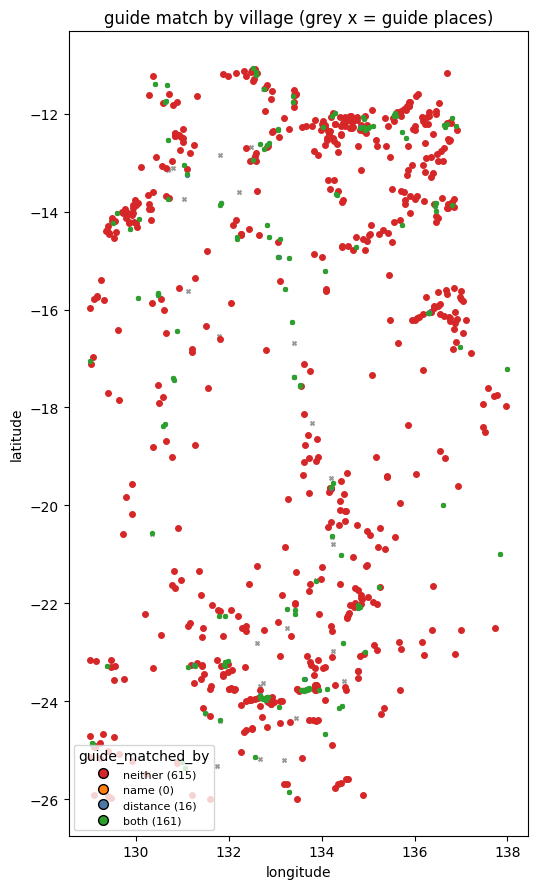

In [13]:
print("guide_matched_by:")
print(village_gap_df["guide_matched_by"].value_counts())
print("\nby_distance x by_name:")
print(pd.crosstab(village_gap_df["_by_distance"].rename("within_2km"),
                  village_gap_df["_by_name"].rename("name_match")))
print(f"\nof matched villages: guide_says_covered True "
      f"{int((village_gap_df['guide_says_covered'] == True).sum())}, "
      f"guide_proximity_only True {int((village_gap_df['guide_proximity_only'] == True).sum())}")

fig, ax = plt.subplots(figsize=(7.5, 9))
guide_3577.to_crs("EPSG:4326").plot(ax=ax, color="0.6", marker="x", markersize=8)
handles = []
for mb, colour in [("neither", "#d62728"), ("name", "#ff7f0e"), ("distance", "#4c78a8"), ("both", "#2ca02c")]:
    sub = villages_gdf[villages_gdf["community_id"].isin(
        village_gap_df.loc[village_gap_df["guide_matched_by"] == mb, "community_id"])]
    if len(sub):
        sub.plot(ax=ax, color=colour, markersize=(8 if mb != "neither" else 16))
    handles.append(Line2D([], [], marker="o", color="none", markerfacecolor=colour, markersize=7,
                          label=f"{mb} ({len(sub)})"))
ax.legend(handles=handles, fontsize=8, loc="lower left", title="guide_matched_by")
ax.set_title("guide match by village (grey x = guide places)")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
fig.tight_layout()
eda_figures["06_guide_match_breakdown"] = fig

## 7. RICT public access (from nb 05) — *straight-line*

`has_rict_public_access` = at least one RICT site within `RICT_MATCH_KM`. `n_rict_sites` is
how many, `rict_site_type` the `;`-joined distinct codes (`CP` community phone · `WP` Wi-Fi phone · `CPW` community phone + Wi-Fi · `WH` Wi-Fi hotspot).

In [14]:
rict_df = program_sites_df[program_sites_df["source"] == "rict"].copy()
rict_3577 = points_3577(rict_df)

rict_buffers = village_pts_3577.copy()
rict_buffers["geometry"] = rict_buffers.buffer(RICT_MATCH_KM * 1000)
rhits = gpd.sjoin(rict_buffers, rict_3577[["program_site_id", "rict_site_type", "geometry"]],
                  how="left", predicate="intersects")
rgrp = rhits.groupby("community_id")
rict_agg = pd.DataFrame({
    "n_rict_sites": rgrp["program_site_id"].nunique(),
    "rict_site_type": rgrp["rict_site_type"].apply(
        lambda s: ";".join(sorted({x for x in s.dropna()})) or np.nan),
}).reset_index()
village_gap_df = village_gap_df.merge(rict_agg, on="community_id", how="left")
village_gap_df["n_rict_sites"] = village_gap_df["n_rict_sites"].fillna(0).astype(int)
village_gap_df["has_rict_public_access"] = village_gap_df["n_rict_sites"] > 0

# nearest RICT distance — for the validation histogram only, not written
_nr = gpd.sjoin_nearest(village_pts_3577[["community_id", "geometry"]],
                        rict_3577[["program_site_id", "geometry"]], how="left", distance_col="_m"
                        ).sort_values("_m").drop_duplicates("community_id")
_km_nearest_rict = (_nr.set_index("community_id")["_m"] / 1000)

### Validate: nearest-RICT distance, and RICT sites that match no village

has_rict_public_access: 274 / 792
count    792.00
mean      25.49
std       35.91
min        0.00
25%        0.13
50%        9.60
75%       36.87
max      185.45
Name: _m, dtype: float64

RICT sites with NO village within 2 km: 12 / 296


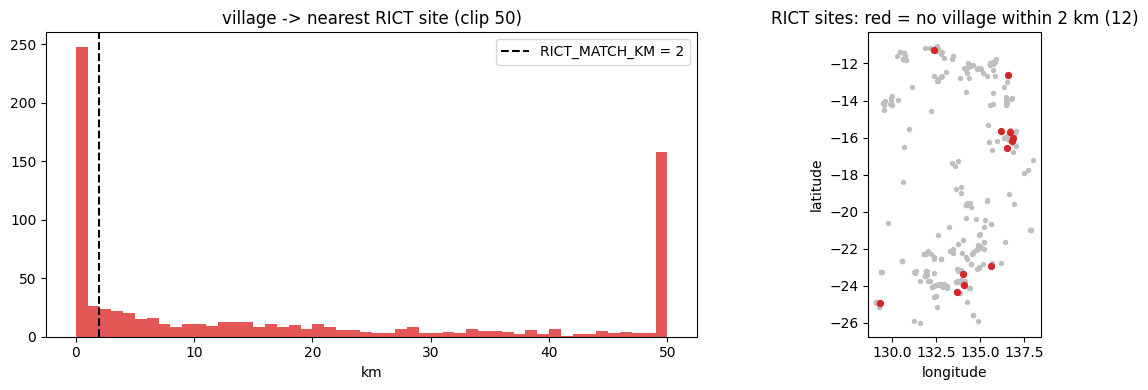

In [15]:
print(f"has_rict_public_access: {int(village_gap_df['has_rict_public_access'].sum())} / {len(village_gap_df)}")
print(_km_nearest_rict.describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(_km_nearest_rict.clip(upper=50), bins=50, color="#e45756")
axes[0].axvline(RICT_MATCH_KM, color="k", linestyle="--", label=f"RICT_MATCH_KM = {RICT_MATCH_KM}")
axes[0].set_title("village -> nearest RICT site (clip 50)"); axes[0].set_xlabel("km"); axes[0].legend()

# which RICT sites have no village within RICT_MATCH_KM
rict_to_village = gpd.sjoin_nearest(rict_3577[["program_site_id", "geometry"]],
                                    village_pts_3577[["community_id", "geometry"]],
                                    how="left", distance_col="_m").sort_values("_m").drop_duplicates("program_site_id")
rict_unmatched = rict_to_village[rict_to_village["_m"] > RICT_MATCH_KM * 1000]
print(f"\nRICT sites with NO village within {RICT_MATCH_KM} km: {len(rict_unmatched)} / {len(rict_3577)}")
rict_3577.to_crs("EPSG:4326").plot(ax=axes[1], color="0.75", markersize=8)
_ru = rict_3577[rict_3577["program_site_id"].isin(rict_unmatched["program_site_id"])]
if len(_ru):
    _ru.to_crs("EPSG:4326").plot(ax=axes[1], color="#d62728", markersize=18)
axes[1].set_title(f"RICT sites: red = no village within {RICT_MATCH_KM} km ({len(rict_unmatched)})")
axes[1].set_xlabel("longitude"); axes[1].set_ylabel("latitude")
fig.tight_layout()
eda_figures["06_rict_validation"] = fig

## 8. `distance_gap_candidate` and the `tier` stub

`distance_gap_candidate` = the coverage guide does **not** claim macro or small coverage for
this village (unmatched counts as "no claim") **and** the nearest real tower is more than
`GAP_KM` away. It is a *triage shortlist*, not a verdict — proximity claims are ignored on
purpose and there is no population in it.

In [16]:
not_guide_covered = ~village_gap_df["guide_says_covered"].fillna(False).astype(bool)
village_gap_df["distance_gap_candidate"] = (
    not_guide_covered & (village_gap_df["km_nearest_tower"] > GAP_KM))

# TODO: tier T1-T5 to be defined after this table is reviewed. Stub = missing.
village_gap_df["tier"] = pd.NA

### Validate: `distance_gap_candidate` vs `guide_proximity_only`

distance_gap_candidate: 384 / 792

crosstab distance_gap_candidate x guide_proximity_only (NaN = guide-unmatched):
guide_proximity_only    False  True  unmatched
distance_gap_candidate                        
False                      77    91        240
True                        0     9        375

distance_gap_candidate x is_remote:
is_remote               False  True 
distance_gap_candidate              
False                      13    395
True                        0    384


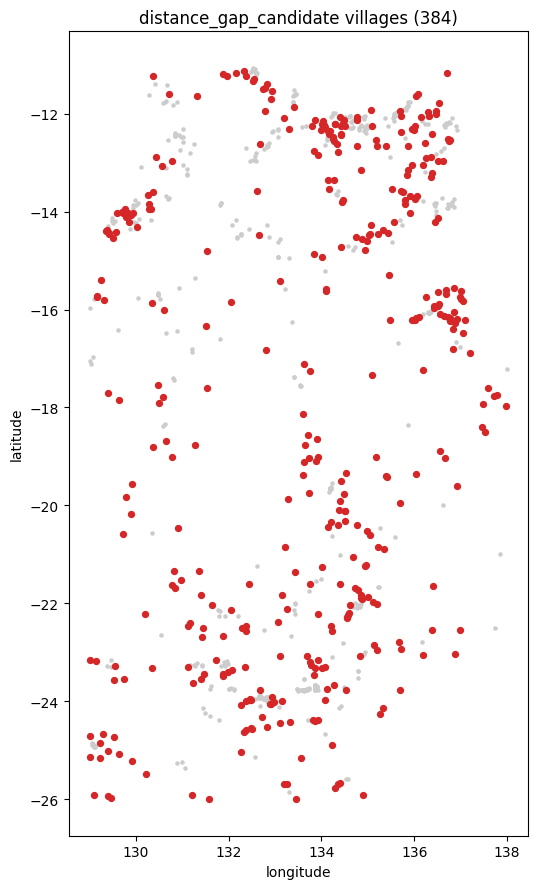

In [17]:
print(f"distance_gap_candidate: {int(village_gap_df['distance_gap_candidate'].sum())} / {len(village_gap_df)}")
print("\ncrosstab distance_gap_candidate x guide_proximity_only (NaN = guide-unmatched):")
print(pd.crosstab(village_gap_df["distance_gap_candidate"],
                  village_gap_df["guide_proximity_only"].astype("object").fillna("unmatched"),
                  dropna=False))
print("\ndistance_gap_candidate x is_remote:")
print(pd.crosstab(village_gap_df["distance_gap_candidate"], village_gap_df["is_remote"]))

fig, ax = plt.subplots(figsize=(7.5, 9))
villages_gdf.plot(ax=ax, color="0.8", markersize=5)
_cand = villages_gdf[villages_gdf["community_id"].isin(
    village_gap_df.loc[village_gap_df["distance_gap_candidate"], "community_id"])]
if len(_cand):
    _cand.plot(ax=ax, color="#d62728", markersize=18)
ax.set_title(f"distance_gap_candidate villages "
             f"({int(village_gap_df['distance_gap_candidate'].sum())})")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
fig.tight_layout()
eda_figures["06_distance_gap_candidate_map"] = fig

## 9. Assemble `village_gap.csv` — explicit column list

In [18]:
VILLAGE_GAP_COLUMNS = [
    "community_id", "community_name", "community_aliases", "community_type", "latitude", "longitude",
    "sa1_code", "remoteness_name", "is_remote",
    "km_nearest_tower", "nearest_tower_carriers", "nearest_tower_networks", "nearest_tower_spectrum_depth_khz",
    "n_towers_10km", "n_carriers_10km", "n_networks_10km",
    "in_nbn_fixed_line", "in_nbn_fixed_wireless",
    "km_nearest_built_mbsp", "km_nearest_unbuilt_mbsp", "nearest_unbuilt_mbsp_round",
    "guide_match_name", "guide_match_km", "guide_matched_by", "guide_says_covered", "guide_proximity_only",
    "has_rict_public_access", "n_rict_sites", "rict_site_type",
    "distance_gap_candidate", "tier",
]
village_gap_out_df = (village_gap_df[VILLAGE_GAP_COLUMNS]
                      .sort_values("community_id").reset_index(drop=True))

assert list(village_gap_out_df.columns) == VILLAGE_GAP_COLUMNS, "column set / order changed"
assert len(village_gap_out_df) == 792 and village_gap_out_df["community_id"].is_unique
for c in ["km_nearest_tower", "n_towers_10km", "n_carriers_10km", "n_networks_10km",
          "in_nbn_fixed_line", "in_nbn_fixed_wireless", "km_nearest_built_mbsp",
          "km_nearest_unbuilt_mbsp", "guide_matched_by", "has_rict_public_access",
          "n_rict_sites", "distance_gap_candidate"]:
    assert village_gap_out_df[c].notna().all(), f"{c} has nulls it should not"
# these are legitimately NaN when the village has no guide match
assert (village_gap_out_df["guide_match_name"].isna() ==
        village_gap_out_df["guide_matched_by"].eq("neither")).all()
village_gap_out_df.head()

,community_id,community_name,community_aliases,community_type,latitude,longitude,sa1_code,remoteness_name,is_remote,km_nearest_tower,nearest_tower_carriers,nearest_tower_networks,nearest_tower_spectrum_depth_khz,n_towers_10km,n_carriers_10km,n_networks_10km,in_nbn_fixed_line,in_nbn_fixed_wireless,km_nearest_built_mbsp,km_nearest_unbuilt_mbsp,nearest_unbuilt_mbsp_round,guide_match_name,guide_match_km,guide_matched_by,guide_says_covered,guide_proximity_only,has_rict_public_access,n_rict_sites,rict_site_type,distance_gap_candidate,tier
0,1,ADELAIDE BORE,"WOOLA,WOOLLA",Family Outstation,-22.21485,133.93607,70201105410,Very Remote Australia,True,52.67,Telstra,Telstra,55000.0,0,0,0,False,False,79.14,119.92,Round 7,NaN,NaN,neither,<NA>,<NA>,True,1,CP,True,<NA>
1,2,ALYUEN,"AILERON,ALUM,ALUM CAMP",Family Outstation,-22.66949,133.35147,70201105410,Very Remote Australia,True,2.87,Optus,Optus,35000.0,1,1,1,False,False,96.46,193.50,Round 7,NaN,NaN,neither,<NA>,<NA>,False,0,NaN,False,<NA>
2,3,AKNGWERTNARRE,MORRIS SOAK,Town Camp,-23.69280,133.86120,70201104513,Remote Australia,True,0.72,Optus;TPG,Optus;TPG,75000.0,20,4,3,True,False,57.37,280.63,Round 7,NaN,NaN,neither,<NA>,<NA>,True,1,WP,False,<NA>
3,4,ALKIPI,"ALKIPIE,ALKPIE,MOUNT LARRY,YALKIPI",Family Outstation,-23.27356,131.82924,70201105310,Very Remote Australia,True,13.27,Telstra,Telstra,59900.0,0,0,0,False,False,55.95,348.28,Round 7,NaN,NaN,neither,<NA>,<NA>,False,0,NaN,False,<NA>
4,5,RED SANDHILL,INTJIRRANGA,Family Outstation,-24.00974,132.85279,70201105312,Very Remote Australia,True,10.79,Telstra,Telstra,58900.0,0,0,0,False,False,12.50,348.47,Round 7,NaN,NaN,neither,<NA>,<NA>,True,2,WP,False,<NA>


In [19]:
# Second-to-last cell: summary print.
g = village_gap_out_df
print("06_village_gap — summary")
print("-" * 64)
print(f"rows out : {len(g)} villages, one per community_id")
print(f"km_nearest_tower   : median {g['km_nearest_tower'].median():.1f}, "
      f"p90 {g['km_nearest_tower'].quantile(.9):.1f}, max {g['km_nearest_tower'].max():.1f}; "
      f"{int((g['km_nearest_tower'] > GAP_KM).sum())} villages > {GAP_KM} km")
print(f"within 10 km       : {int((g['n_towers_10km'] == 0).sum())} villages have 0 towers; "
      f"n_networks_10km 0/{int((g['n_networks_10km']==0).sum())} 1/{int((g['n_networks_10km']==1).sum())} "
      f"2/{int((g['n_networks_10km']==2).sum())} 3/{int((g['n_networks_10km']==3).sum())}")
print(f"NBN fixed          : line {int(g['in_nbn_fixed_line'].sum())}, wireless {int(g['in_nbn_fixed_wireless'].sum())}")
print(f"guide match        : {g['guide_matched_by'].value_counts().to_dict()}")
print(f"guide_says_covered : {int((g['guide_says_covered'] == True).sum())} True, "
      f"proximity_only {int((g['guide_proximity_only'] == True).sum())} True")
print(f"RICT               : {int(g['has_rict_public_access'].sum())} villages have a RICT site within {RICT_MATCH_KM} km")
print(f"distance_gap_candidate : {int(g['distance_gap_candidate'].sum())}  "
      f"({int((g['distance_gap_candidate'] & g['is_remote']).sum())} of them Remote/Very Remote)")
print("tier              : stub (<NA>) — define T1-T5 after review")

06_village_gap — summary
----------------------------------------------------------------
rows out : 792 villages, one per community_id
km_nearest_tower   : median 14.1, p90 53.0, max 149.6; 384 villages > 15 km
within 10 km       : 470 villages have 0 towers; n_networks_10km 0/470 1/221 2/39 3/62
NBN fixed          : line 30, wireless 1
guide match        : {'neither': 615, 'both': 161, 'distance': 16}
guide_says_covered : 77 True, proximity_only 100 True
RICT               : 274 villages have a RICT site within 2 km
distance_gap_candidate : 384  (384 of them Remote/Very Remote)
tier              : stub (<NA>) — define T1-T5 after review


In [20]:
# Last cell: every file write.
csv_path     = OUT_DIR / "village_gap.csv"
geojson_path = OUT_DIR / "village_gap.geojson"

village_gap_out_df.to_csv(csv_path, index=False)
gpd.GeoDataFrame(
    village_gap_out_df.copy(),
    geometry=gpd.points_from_xy(village_gap_out_df["longitude"], village_gap_out_df["latitude"]),
    crs="EPSG:4326",
).to_file(geojson_path, driver="GeoJSON")

for name, fig in eda_figures.items():
    fig.savefig(EDA_PLOT_DIR / f"{name}.png", dpi=120, bbox_inches="tight")

print("wrote:")
print(" ", csv_path, f"({len(village_gap_out_df)} rows)")
print(" ", geojson_path)
for name in eda_figures:
    print("  docs/eda/" + name + ".png")

wrote:
  data\processed\village_gap.csv (792 rows)
  data\processed\village_gap.geojson
  docs/eda/06_km_nearest_tower_hist.png
  docs/eda/06_sample_village_tower_lines.png
  docs/eda/06_villages_vs_nbn.png
  docs/eda/06_mbsp_distance_hist.png
  docs/eda/06_guide_match_breakdown.png
  docs/eda/06_rict_validation.png
  docs/eda/06_distance_gap_candidate_map.png
